In [9]:
# ------ Librerias-----

import json
import os
from datetime import datetime

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    make_scorer,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from xgboost import XGBClassifier

In [10]:
# ==============================================================================
# 1. CARGA DE DATOS Y FEATURE ENGINEERING BASE
# ==============================================================================
df = pd.read_csv("Archivos_aux/datos_fraud.csv")

# Transformaciones sobre el monto de la transacción
df['amount'] = df['amount'].astype(np.float64)
df['amount_log'] = np.log1p(df['amount'])
df['es_uno_o_menos'] = (df['amount'] <= 1.0).astype(int)
df['es_cero'] = (df['amount'] == 0.0).astype(int)

# Transformaciones sobre el tiempo
df['hour'] = ((df['timestamp'] / 3600) % 24).astype(int)
df['day'] = ((df['timestamp'] / 86400)).astype(int) + 1
df['is_night_transaction'] = (
    (df['hour'] >= 0) & (df['hour'] <= 5)
).astype(int)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)


In [11]:

# ==============================================================================
# 2. SEPARACIÓN ESTRATIFICADA (TRAIN / TEST)
# ==============================================================================
X = df.drop(columns=['is_fraud', 'transaction_id', 'amount', 'timestamp'])
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ==============================================================================
# 3. DISCRETIZACIÓN DE DECILES (SOLO CON INFORMACIÓN DE TRAIN)
# ==============================================================================
_, bin_edges = pd.qcut(
    X_train['amount_log'], q=10, labels=False, retbins=True, duplicates='drop'
)
bin_edges[0] = -float('inf')
bin_edges[-1] = float('inf')

X_train['deciles'] = pd.cut(
    X_train['amount_log'], bins=bin_edges, labels=False, include_lowest=True
)
X_test['deciles'] = pd.cut(
    X_test['amount_log'], bins=bin_edges, labels=False, include_lowest=True
)


In [12]:

# ==============================================================================
# 4. CONFIGURACIÓN E INSTANCIACIÓN DE MODELO HYPEROPTIMIZADO
# ==============================================================================
scale_pos_weight_value = (len(y_train) - sum(y_train)) / sum(y_train)

params_xgb = {
    'n_estimators': 1500,
    'learning_rate': 0.051649232072272615,
    'max_depth': 5,
    'subsample': 0.9658075634630385,
    'colsample_bytree': 0.6261278549784421,
    'scale_pos_weight': 201.2089646115566,
    'reg_alpha': 0.0013332399017578604,
    'reg_lambda': 0.1381424424249814,
    'gamma': 0.00010212425872946351,
    'random_state': 42,
    'n_jobs': -1,
    'eval_metric': 'aucpr',
    'early_stopping_rounds': 20,
}


In [13]:

# ==============================================================================
# 5. ENTRENAMIENTO FINAL CON EARLY STOPPING EN VALIDACIÓN INTERNA
# ==============================================================================
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

print("Entrenando modelo final XGBoost con Early Stopping...")
final_xgb_model = XGBClassifier(**params_xgb)
final_xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

print(
    f"✅ Entrenamiento detenido en el árbol {final_xgb_model.best_iteration} (de"
    f" {final_xgb_model.n_estimators} máximos)."
)

# ==============================================================================
# 6. CÁLCULO DEL UMBRAL ÓPTIMO EN VALIDACIÓN (SIN DATA LEAKAGE)
# ==============================================================================
y_probs_val = final_xgb_model.predict_proba(X_val)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, y_probs_val)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
OPTIMAL_THRESHOLD = float(thresholds[best_idx])

print(f"\n==================================================")
print(f"   UMBRAL ÓPTIMO CONFIGURADO (EN VALIDACIÓN): {OPTIMAL_THRESHOLD:.4f}")
print(f"   Precisión esperada en Val: {precisions[best_idx]:.4f}")
print(f"   Recall esperado en Val:    {recalls[best_idx]:.4f}")
print(f"   F1-Score máximo en Val:    {f1_scores[best_idx]:.4f}")
print(f"==================================================\n")


Entrenando modelo final XGBoost con Early Stopping...
✅ Entrenamiento detenido en el árbol 116 (de 1500 máximos).

   UMBRAL ÓPTIMO CONFIGURADO (EN VALIDACIÓN): 0.9812
   Precisión esperada en Val: 1.0000
   Recall esperado en Val:    0.8475
   F1-Score máximo en Val:    0.9174



In [14]:

# ==============================================================================
# 7. CLASE ENCAPSULADORA PARA PRODUCCIÓN (WRAPPER COMPLETO DE PIPELINE)
# ==============================================================================
class ProductionFraudClassifier:
    """Wrapper de producción que garantiza consistencia en las transformaciones
    de variables (incluyendo deciles) y aplica automáticamente el umbral.
    """

    def __init__(self, model, threshold: float, bin_edges: np.ndarray):
        self.model = model
        self.threshold = threshold
        self.bin_edges = bin_edges
        self.feature_names = getattr(model, 'feature_names_in_', None)

    def _preprocess(self, X_input: pd.DataFrame) -> pd.DataFrame:
        X = X_input.copy()
        if 'deciles' not in X.columns and 'amount_log' in X.columns:
            X['deciles'] = pd.cut(
                X['amount_log'],
                bins=self.bin_edges,
                labels=False,
                include_lowest=True,
            )
        return X

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        X_proc = self._preprocess(X)
        return self.model.predict_proba(X_proc)

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        probs = self.predict_proba(X)[:, 1]
        return (probs >= self.threshold).astype(int)


# Instanciar el detector listo para producción
fraud_detector_final = ProductionFraudClassifier(
    model=final_xgb_model,
    threshold=OPTIMAL_THRESHOLD,
    bin_edges=bin_edges,
)


✅ Modelo guardado exitosamente en 'Salidas/Modelos_finales/modelo_fraude_xgboost_final.joblib'


            INFORME ESTADÍSTICO DE DESEMPEÑO DEL MODELO FINAL

[TABLA 1: DIAGNÓSTICO DE OVERFITTING Y GENERALIZACIÓN]
    Métrica Evaluada Entrenamiento (X_tr) Prueba (X_test) Gap Generalización
  PR-AUC (Principal)               0.9637          0.8738             0.0899
ROC-AUC (Secundaria)               0.9999          0.9859             0.0140

[TABLA 2: RESUMEN DE DESEMPEÑO EN PRODUCCIÓN (TEST)]
                       Métrica de Negocio    Valor Obtenido
              Umbral de Decisión Aplicado            0.9812
          Precisión en Fraude (Precision)    0.9630 (96.3%)
             Cobertura de Fraude (Recall)    0.7959 (79.6%)
      F1-Score (Balance Precisión/Recall)            0.8715
F2-Score (Mayor peso al Recall de Fraude)            0.8245
             Tasa de Falsas Alarmas (FPR) 0.0053% (3 casos)


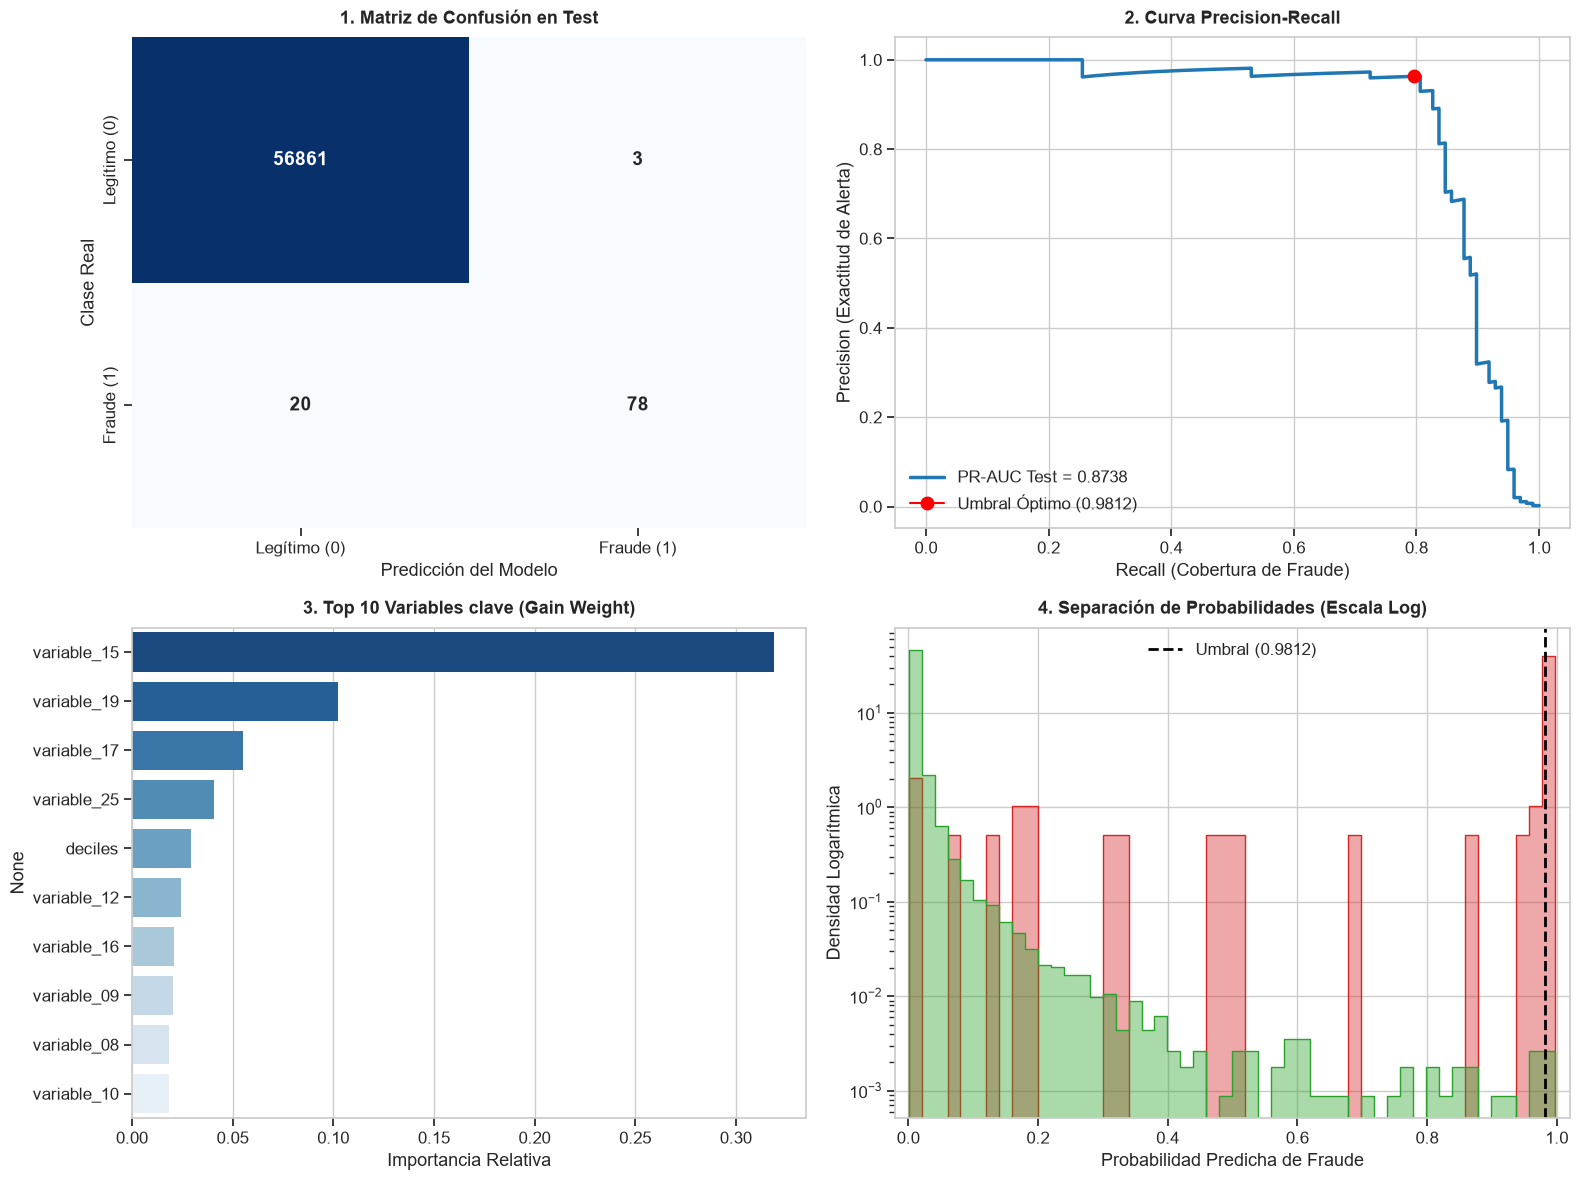

✅ Archivo de metadatos guardado exitosamente en: 'Salidas/Modelos_finales/model_metadata.json'


In [15]:

# ==============================================================================
# 8. GUARDAR ARTEFACTO COMPLETO A DISCO
# ==============================================================================
os.makedirs("Salidas/Modelos_finales", exist_ok=True)
file_name = 'Salidas/Modelos_finales/modelo_fraude_xgboost_final.joblib'
joblib.dump(fraud_detector_final, file_name)
print(f"✅ Modelo guardado exitosamente en '{file_name}'")

# ==============================================================================
# 9. EVALUACIÓN Y GENERACIÓN DEL DASHBOARD Y REPORTES EN TEST
# ==============================================================================
plt.style.use(
    'seaborn-v0_8-whitegrid'
    if 'seaborn-v0_8-whitegrid' in plt.style.available
    else 'default'
)
sns.set_context('notebook', font_scale=1.1)

y_probs_tr = fraud_detector_final.predict_proba(X_tr)[:, 1]
y_probs_te = fraud_detector_final.predict_proba(X_test)[:, 1]

y_pred_te = (y_probs_te >= OPTIMAL_THRESHOLD).astype(int)

pr_auc_tr = average_precision_score(y_tr, y_probs_tr)
pr_auc_te = average_precision_score(y_test, y_probs_te)
roc_auc_tr = roc_auc_score(y_tr, y_probs_tr)
roc_auc_te = roc_auc_score(y_test, y_probs_te)

report_dict = classification_report(y_test, y_pred_te, output_dict=True)
prec_1 = report_dict['1']['precision']
rec_1 = report_dict['1']['recall']
f1_1 = report_dict['1']['f1-score']
f2_1 = fbeta_score(y_test, y_pred_te, beta=2)

cm = confusion_matrix(y_test, y_pred_te)
tn, fp, fn, tp = cm.ravel()
total_legit = tn + fp
total_fraud = fn + tp

print("=" * 75)
print("            INFORME ESTADÍSTICO DE DESEMPEÑO DEL MODELO FINAL")
print("=" * 75)

df_fit = pd.DataFrame({
    'Métrica Evaluada': ['PR-AUC (Principal)', 'ROC-AUC (Secundaria)'],
    'Entrenamiento (X_tr)': [f'{pr_auc_tr:.4f}', f'{roc_auc_tr:.4f}'],
    'Prueba (X_test)': [f'{pr_auc_te:.4f}', f'{roc_auc_te:.4f}'],
    'Gap Generalización': [
        f'{(pr_auc_tr - pr_auc_te):.4f}',
        f'{(roc_auc_tr - roc_auc_te):.4f}',
    ],
})
print('\n[TABLA 1: DIAGNÓSTICO DE OVERFITTING Y GENERALIZACIÓN]')
print(df_fit.to_string(index=False))

df_metrica_operativa = pd.DataFrame({
    'Métrica de Negocio': [
        'Umbral de Decisión Aplicado',
        'Precisión en Fraude (Precision)',
        'Cobertura de Fraude (Recall)',
        'F1-Score (Balance Precisión/Recall)',
        'F2-Score (Mayor peso al Recall de Fraude)',
        'Tasa de Falsas Alarmas (FPR)',
    ],
    'Valor Obtenido': [
        f'{OPTIMAL_THRESHOLD:.4f}',
        f'{prec_1:.4f} ({prec_1:.1%})',
        f'{rec_1:.4f} ({rec_1:.1%})',
        f'{f1_1:.4f}',
        f'{f2_1:.4f}',
        f'{(fp / total_legit):.4%} ({fp} casos)',
    ],
})
print('\n[TABLA 2: RESUMEN DE DESEMPEÑO EN PRODUCCIÓN (TEST)]')
print(df_metrica_operativa.to_string(index=False))

# Generación del Dashboard Gráfico
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Gráfico 1: Matriz de Confusión ---
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    ax=axes[0, 0],
    annot_kws={'size': 14, 'weight': 'bold'},
    xticklabels=['Legítimo (0)', 'Fraude (1)'],
    yticklabels=['Legítimo (0)', 'Fraude (1)'],
)
axes[0, 0].set_title(
    '1. Matriz de Confusión en Test', fontsize=13, fontweight='bold', pad=10
)
axes[0, 0].set_xlabel('Predicción del Modelo')
axes[0, 0].set_ylabel('Clase Real')

# --- Gráfico 2: Curva Precision-Recall ---
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_probs_te)
axes[0, 1].plot(
    rec_curve,
    prec_curve,
    color='#1f77b4',
    lw=2.5,
    label=f'PR-AUC Test = {pr_auc_te:.4f}',
)
axes[0, 1].plot(
    rec_1,
    prec_1,
    marker='o',
    markersize=9,
    color='red',
    label=f'Umbral Óptimo ({OPTIMAL_THRESHOLD:.4f})',
)
axes[0, 1].set_title(
    '2. Curva Precision-Recall', fontsize=13, fontweight='bold', pad=10
)
axes[0, 1].set_xlabel('Recall (Cobertura de Fraude)')
axes[0, 1].set_ylabel('Precision (Exactitud de Alerta)')
axes[0, 1].legend(loc='lower left')

# --- Gráfico 3: Feature Importance ---
importances = pd.Series(
    fraud_detector_final.model.feature_importances_, index=X_tr.columns
).sort_values(ascending=False)[:10]

sns.barplot(
    x=importances.values,
    y=importances.index,
    palette='Blues_r',
    ax=axes[1, 0],
    hue=importances.index,
    legend=False,
)
axes[1, 0].set_title(
    '3. Top 10 Variables clave (Gain Weight)',
    fontsize=13,
    fontweight='bold',
    pad=10,
)
axes[1, 0].set_xlabel('Importancia Relativa')

# --- Gráfico 4: Separación de Probabilidades (Índice Limpio) ---
df_probs = pd.DataFrame({
    'Probabilidad': y_probs_te,
    'Clase': pd.Series(y_test.values).map(
        {0: 'Legítimo (0)', 1: 'Fraude (1)'}
    ),
})

sns.histplot(
    data=df_probs,
    x='Probabilidad',
    hue='Clase',
    bins=50,
    element='step',
    stat='density',
    common_norm=False,
    palette={'Legítimo (0)': '#2ca02c', 'Fraude (1)': '#d62728'},
    alpha=0.4,
    ax=axes[1, 1],
)

axes[1, 1].axvline(
    OPTIMAL_THRESHOLD,
    color='black',
    linestyle='--',
    linewidth=2,
    label=f'Umbral ({OPTIMAL_THRESHOLD:.4f})',
)
axes[1, 1].set_yscale('log')
axes[1, 1].set_xlim(-0.02, 1.02)
axes[1, 1].set_title(
    '4. Separación de Probabilidades (Escala Log)',
    fontsize=13,
    fontweight='bold',
    pad=10,
)
axes[1, 1].set_xlabel('Probabilidad Predicha de Fraude')
axes[1, 1].set_ylabel('Densidad Logarítmica')

handles, labels = axes[1, 1].get_legend_handles_labels()
axes[1, 1].legend(handles=handles, labels=labels, loc='upper center')

plt.tight_layout()
plt.show()

# ==============================================================================
# 10. EXPORTACIÓN DE METADATOS EN JSON
# ==============================================================================
metadata = {
    "model_info": {
        "model_name": "Fraud_Detector_XGBoost",
        "model_version": "1.0.0",
        "description": (
            "Modelo supervisado para detección de fraude transaccional"
            " altamente desbalanceado."
        ),
        "author": "Equipo de Data Science / Analytics",
        "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "framework": "xgboost / scikit-learn",
        "algorithm": fraud_detector_final.model.__class__.__name__,
    },
    "decision_threshold": {
        "optimal_threshold": float(OPTIMAL_THRESHOLD),
        "threshold_metric_criterion": "F1-Score / Precision-Recall Optimization",
    },
    "data_schema": {
        "target_variable": "is_fraud",
        "num_features": len(X_tr.columns),
        "feature_names": list(X_tr.columns),
    },
    "hyperparameters": {
        k: (float(v) if isinstance(v, (np.float32, np.float64)) else v)
        for k, v in fraud_detector_final.model.get_params().items()
    },
    "performance_metrics": {
        "test_set": {
            "pr_auc": float(pr_auc_te),
            "roc_auc": float(roc_auc_te),
            "precision": float(prec_1),
            "recall": float(rec_1),
            "f1_score": float(f1_1),
            "f2_score": float(f2_1),
            "false_positive_rate": float(fp / total_legit),
        },
        "confusion_matrix_test": {
            "true_negatives_TN": int(tn),
            "false_positives_FP": int(fp),
            "false_negatives_FN": int(fn),
            "true_positives_TP": int(tp),
        },
        "generalization_gap": {
            "pr_auc_gap": float(pr_auc_tr - pr_auc_te),
            "roc_auc_gap": float(roc_auc_tr - roc_auc_te),
        },
    },
    "feature_importance_top10": importances.to_dict(),
}

json_filepath = "Salidas/Modelos_finales/model_metadata.json"
with open(json_filepath, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

print(f"✅ Archivo de metadatos guardado exitosamente en: '{json_filepath}'")